In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import random

### 读取数据集并查看

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [3]:
train_data = pd.read_csv(r"DataSet\train.csv")
test_data = pd.read_csv(r"DataSet\test.csv")
train_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [4]:
# 下面的代码是为了填充数据中的缺失值
for col in train_data.columns:
    if col == "SalePrice" or col == "Id":   # 跳过标签列和ID列
        continue
    if pd.api.types.is_numeric_dtype(train_data[col]):  # 判断是否为连续数值型数据
        fill_value = train_data[col].mean()
        # 保持整数类型
        if pd.api.types.is_integer_dtype(train_data[col]):
            fill_value = int(round(fill_value))
        else:
            # 保留原有小数位数
            decimals = train_data[col].apply(lambda x: str(x)[::-1].find('.') if '.' in str(x) else 0).max()
            fill_value = round(float(fill_value), decimals)
        train_data[col].fillna(fill_value, inplace=True)
    else:  # 如果是分类数据
        fill_value = train_data[col].mode()[0]
        train_data[col].fillna(fill_value, inplace=True)

# 对测试数据也进行相同的处理
for col in test_data.columns:
    if col == "Id":   # 跳过ID列
        continue
    if pd.api.types.is_numeric_dtype(test_data[col]):  # 判断是否为连续数值型数据
        fill_value = test_data[col].mean()
        if pd.api.types.is_integer_dtype(test_data[col]):
            fill_value = int(round(fill_value))
        else:
            decimals = test_data[col].apply(lambda x: str(x)[::-1].find('.') if '.' in str(x) else 0).max()
            fill_value = round(float(fill_value), decimals)
        test_data[col].fillna(fill_value, inplace=True)
    else:  # 如果是分类数据
        fill_value = test_data[col].mode()[0]
        test_data[col].fillna(fill_value, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31052\2212766668.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data[col].fillna(fill_value, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31052\2212766668.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [5]:
noise_example = train_data.sample(1).copy()
train_mean = {col: train_data[col].mean() for col in train_data.columns if pd.api.types.is_numeric_dtype(train_data[col])}
train_std = {col: train_data[col].std() for col in train_data.columns if pd.api.types.is_numeric_dtype(train_data[col])}
#用字典存储对应的事先计算的均值与标准差，避免反复计算

for col in noise_example.columns:
    if col == "Id":
        noise_example[col] = train_data[col].max() + 1
    elif pd.api.types.is_numeric_dtype(train_data[col]):
        value = np.random.normal(loc=train_mean[col], scale=train_std[col])
        # 保证生成数据非负，因为一间房子的面积之类的数值不能为负数是吧
        value = np.clip(value, 0, None)
        # 保持格式
        if pd.api.types.is_integer_dtype(train_data[col]):
            value = int(round(value))
        else:
            # 保留与原数据相同的小数位数
            decimals = train_data[col].apply(lambda x: str(x)[::-1].find('.') if '.' in str(x) else 0).max()
            value = round(float(value), decimals)
        noise_example[col] = value
    else:
        noise_example[col] = np.random.choice(train_data[col])

noise_example


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
892,1461,83,RM,58.9,4151,Pave,Grvl,IR1,Lvl,AllPub,...,12,Gd,MnPrv,Shed,0,6,2010,WD,Normal,161199


In [6]:
def add_noise_samples(df, n_noise=1, id_col="Id", label_col="SalePrice"):
    df = df.copy()
    numeric_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col]) and col != id_col]
    categorical_cols = [col for col in df.columns if not pd.api.types.is_numeric_dtype(df[col]) and col != id_col]
    means = {col: df[col].mean() for col in numeric_cols}
    stds = {col: df[col].std() for col in numeric_cols}
    noise_rows = []
    for _ in range(n_noise):
        noise = {}
        for col in df.columns:
            if col == id_col:
                noise[col] = df[col].max() + 1 + _
            elif col in numeric_cols:
                value = np.random.normal(loc=means[col], scale=stds[col])
                # 对标签也做clip
                if col == label_col:
                    value = np.clip(value, 1, None)
                else:
                    value = np.clip(value, 0, None)
                if pd.api.types.is_integer_dtype(df[col]):
                    value = int(round(value))
                else:
                    decimals = df[col].apply(lambda x: str(x)[::-1].find('.') if '.' in str(x) else 0).max()
                    value = round(float(value), decimals)
                noise[col] = value
            elif col in categorical_cols:
                noise[col] = np.random.choice(df[col])
            else:
                noise[col] = np.nan
        noise_rows.append(noise)
    noise_df = pd.DataFrame(noise_rows, columns=df.columns)
    return pd.concat([df, noise_df], ignore_index=True)

In [7]:
train_data = add_noise_samples(train_data,20)
train_data.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1475,1476,82,RL,94.0,8409,Pave,Grvl,Reg,Lvl,AllPub,...,47,Gd,MnPrv,Shed,0,7,2009,WD,Normal,116604
1476,1477,75,RM,45.5,11492,Pave,Grvl,Reg,Lvl,AllPub,...,68,Gd,MnPrv,Shed,0,6,2007,New,Normal,183215
1477,1478,0,RL,68.3,1476,Pave,Grvl,Reg,Lvl,AllPub,...,38,Gd,MnPrv,Shed,0,6,2007,New,Abnorml,187189
1478,1479,58,RL,100.0,0,Pave,Pave,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,656,5,2007,WD,Normal,219254
1479,1480,101,RL,68.4,20208,Pave,Grvl,Reg,Lvl,AllPub,...,10,Gd,MnPrv,Shed,0,7,2006,WD,Normal,247654


In [8]:
train_data = train_data.drop(columns=["Id"])  # 删除ID列
train_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,0,Gd,MnPrv,Shed,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Grvl,Reg,Lvl,AllPub,FR2,...,0,Gd,MnPrv,Shed,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,Grvl,IR1,Lvl,AllPub,Inside,...,0,Gd,MnPrv,Shed,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,Grvl,IR1,Lvl,AllPub,Corner,...,0,Gd,MnPrv,Shed,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,Grvl,IR1,Lvl,AllPub,FR2,...,0,Gd,MnPrv,Shed,0,12,2008,WD,Normal,250000


In [9]:
numeric_cols = [col for col in train_data.columns if pd.api.types.is_numeric_dtype(train_data[col]) and col != "SalePrice"]  # 排除标签列
train_data[numeric_cols] = train_data[numeric_cols].apply(lambda x: (x - x.mean()) / x.std(), axis=0)  # 正则化数值型数据
train_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0.074822,RL,-0.228807,-0.212098,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,-0.07642,Gd,MnPrv,Shed,-0.092767,-1.600225,0.141081,WD,Normal,208500
1,-0.870836,RL,0.453410,-0.097085,Pave,Grvl,Reg,Lvl,AllPub,FR2,...,-0.07642,Gd,MnPrv,Shed,-0.092767,-0.487983,-0.609998,WD,Normal,181500
2,0.074822,RL,-0.092364,0.067935,Pave,Grvl,IR1,Lvl,AllPub,Inside,...,-0.07642,Gd,MnPrv,Shed,-0.092767,0.995005,0.141081,WD,Normal,223500
3,0.311236,RL,-0.456213,-0.102085,Pave,Grvl,IR1,Lvl,AllPub,Corner,...,-0.07642,Gd,MnPrv,Shed,-0.092767,-1.600225,-1.361078,WD,Abnorml,140000
4,0.074822,RL,0.635335,0.368970,Pave,Grvl,IR1,Lvl,AllPub,FR2,...,-0.07642,Gd,MnPrv,Shed,-0.092767,2.107246,0.141081,WD,Normal,250000


In [10]:
#对训练集中的离散分类数据进行独热编码
train_data = pd.get_dummies(train_data, dummy_na=True)

In [ ]:
def preprocess_data(df, enhance_noise=False, n_noise=0, id_col="Id", label_col="SalePrice"):
    df = df.copy()
    # 1. 填补缺失值
    for col in df.columns:
        if col == label_col or col == id_col:
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            fill_value = df[col].mean()
            if pd.api.types.is_integer_dtype(df[col]):
                fill_value = int(round(fill_value))
            else:
                decimals = df[col].apply(lambda x: str(x)[::-1].find('.') if '.' in str(x) else 0).max()
                fill_value = round(float(fill_value), decimals)
            df[col].fillna(fill_value, inplace=True)
        else:
            fill_value = df[col].mode()[0]
            df[col].fillna(fill_value, inplace=True)

    # 2. 数据增强（可选）
    if enhance_noise and n_noise > 0:
        df = add_noise_samples(df, n_noise=n_noise, id_col=id_col)

    # 3. 删除ID列
    if id_col in df.columns:
        df = df.drop(columns=[id_col])

    # 4. 标准化连续特征（排除标签列）
    numeric_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col]) and col != label_col]
    df[numeric_cols] = df[numeric_cols].apply(lambda x: (x - x.mean()) / x.std(), axis=0)

    # 5. 对分类特征独热编码
    df = pd.get_dummies(df, dummy_na=True)

    return df

In [12]:
train_data = pd.read_csv(r'DataSet\train.csv')
test_data = pd.read_csv(r'DataSet\test.csv')

train_data = preprocess_data(train_data,True,100)
test_data = preprocess_data(test_data)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31052\693886218.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(fill_value, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31052\693886218.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [13]:
class LinerRegressionModel(nn.Module):
    def __init__(self, input_dim):  #输入数据集的特征维度数，即DataFrame的特征列数
        super(LinerRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

In [14]:
class DataFrameDataset(Dataset):
    def __init__(self, df, label_col="SalePrice"):  #1.初始化函数，传入数据集和标签列名
        super(DataFrameDataset, self).__init__() #初始化父类
        if label_col in df.columns: # 如果标签列存在,测试集没有标签列
            self.feature = df.drop(columns=[label_col]).values.astype(np.float32)  # 特征数据
        else:
            self.feature = df.values.astype(np.float32)  # 特征数据
        if label_col in df.columns:
            self.labels = df[label_col].values.astype(np.float32).reshape(-1, 1)  # 标签数据

    def __len__(self): #2.魔法方法__len__，返回数据集的长度
        return len(self.feature)    #__len__魔法方法极其重要，它告诉PyTorch数据集的长度，不定义的话会报错

    def __getitem__(self, idx):   #3.魔法方法__getitem__，返回特定索引的数据对
        return torch.tensor(self.feature[idx]), torch.tensor(self.labels[idx])  #__getitem__魔法方法，返回特定索引的数据,一定是一条特征和标签对

In [ ]:
val_data = train_data.sample(frac=0.2, random_state=42)  # 从训练集中随机抽取20%作为验证集
train_data = train_data.drop(val_data.index)  # 剔除验证集数据

val_dataset = DataFrameDataset(val_data)
train_dataset = DataFrameDataset(train_data)

In [16]:
train_data.tail()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_Oth,SaleType_WD,SaleType_nan,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SaleCondition_nan
1554,-0.072075,-1.912852,0.641295,-0.072876,0.381035,-0.569707,-1.252129,-0.206852,0.458761,-0.318805,...,False,True,False,False,False,False,False,True,False,False
1556,0.070431,-1.331020,-0.077013,2.099486,1.276238,-2.372433,-0.571902,1.051539,-0.154578,-0.318805,...,True,False,False,False,False,False,False,True,False,False
1557,-1.354629,0.153340,-0.674556,2.099486,1.276238,-0.897476,-1.106366,0.017861,0.042487,2.620328,...,False,True,False,False,False,False,False,True,False,False
1558,0.260439,-1.697529,-0.690259,-0.796997,-0.514168,-1.421905,-0.474727,-0.594481,-0.982696,0.901682,...,False,True,False,False,False,False,False,True,False,False
1559,-0.808356,1.930908,-0.066983,-0.072876,-1.409371,-1.651343,1.906070,-0.594481,0.239553,-0.237855,...,False,False,False,False,False,False,False,False,True,False


In [77]:
DataLoader_dict = {"train": DataLoader(train_dataset, batch_size=32, shuffle=True),
                   "val": DataLoader(val_dataset, batch_size=4, shuffle=False)} 

In [78]:
DataLoader_dict["train"].dataset.feature

array([[ 0.07043087, -0.23149373, -0.20476814, ...,  1.        ,
         0.        ,  0.        ],
       [-0.87960935,  0.45571014, -0.0882584 , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.07043087, -0.09405295,  0.07890774, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-1.3546295 ,  0.15334044, -0.67455566, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.26043892, -1.6975286 , -0.69025916, ...,  1.        ,
         0.        ,  0.        ],
       [-0.80835634,  1.9309077 , -0.06698271, ...,  0.        ,
         1.        ,  0.        ]], dtype=float32)

In [19]:
def log_rmse(model, val_dataloader):
    loss = torch.nn.MSELoss()
    model.eval()    #模型进入验证模式，这将禁用梯度更新

    preds = torch.clamp(model(torch.tensor(val_dataloader.dataset.feature)), min=1, max=float('inf'))

    targets = torch.clamp(torch.tensor(val_dataloader.dataset.labels), min=1, max=float('inf'))

    rmse = torch.sqrt(loss(torch.log(preds), torch.log(targets))).item()

    return rmse


def train(model,train_dataloader,val_dataloader,optimizer,criterion,num_epochs):
    for epoch in range(num_epochs): #训练轮次，每个epoch都将包含以下步骤
        model.train()
        for x, y in train_dataloader:
            optimizer.zero_grad()   #先清空上个梯度
            output = model(x)   #前向传播，预测输出
            loss = criterion(output, y) #计算损失
            loss.backward() #反向传播，计算梯度
            optimizer.step()    #根据学习率，更新参数
    # 验证
        model.eval()    #模型进入验证模式，这将禁用梯度更新
        val_loss = 0
        with torch.no_grad():   #禁用梯度计算，节省内存和计算资源
            for x, y in val_dataloader:
                output = model(x)   #前向传播，预测输出
                val_loss += criterion(output, y).item() * x.size(0) #计算验证集损失
        val_loss /= len(val_dataloader.dataset)
        val_RE = log_rmse(model, val_dataloader)
        train_RE = log_rmse(model, train_dataloader)
    return model, val_loss, val_RE, train_RE

In [20]:
def custom_kfold_split(df, k=5, random_state=42):
    np.random.seed(random_state)
    indices = np.arange(len(df))
    np.random.shuffle(indices)
    fold_sizes = np.full(k, len(df) // k)
    fold_sizes[:len(df) % k] += 1
    current = 0
    folds = []
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        folds.append(indices[start:stop])
        current = stop
    return folds


def kfold_train(df, label_col="SalePrice", k=5, lr=0.01, batch_size=32, epochs=10):
    folds = custom_kfold_split(df, k=k)
    scores = []
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])
        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]
        train_dataset = DataFrameDataset(train_df, label_col=label_col)
        val_dataset = DataFrameDataset(val_df, label_col=label_col)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        # 初始化模型、优化器、损失函数
        model = LinerRegressionModel(input_dim=train_df.shape[1]-1)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()
        # 训练
        new_model, val_loss,val_RE, train_RE = train(model, train_loader, val_loader, optimizer, criterion, epochs)
        scores.append(val_RE)
        print(f"Fold {i+1}, Val RE: {val_RE:.4f}, Train RE: {train_RE:.4f}")
    print(f"Average Val RE: {np.mean(scores):.4f}")



In [21]:
kfold_train(train_data, label_col="SalePrice", k=5,lr=3, batch_size=4, epochs=200)   #调参

Fold 1, Val RE: 0.1834, Train RE: 0.4063
Fold 2, Val RE: 0.1801, Train RE: 0.4080
Fold 3, Val RE: 0.2347, Train RE: 0.4074
Fold 4, Val RE: 0.1902, Train RE: 0.4092
Fold 5, Val RE: 0.7896, Train RE: 0.1514
Average Val RE: 0.3156


In [22]:
model = LinerRegressionModel(input_dim=train_data.shape[1]-1)
optimizer = torch.optim.Adam(model.parameters(), lr=3)
criterion = nn.MSELoss()
new_model, val_loss,val_RE, train_RE = train(model, DataLoader_dict["train"], DataLoader_dict["val"], optimizer, criterion, 200)
print("Val RE:", val_RE)
print("Train RE:",train_RE)

Val RE: 0.18924324214458466
Train RE: 0.3722364604473114


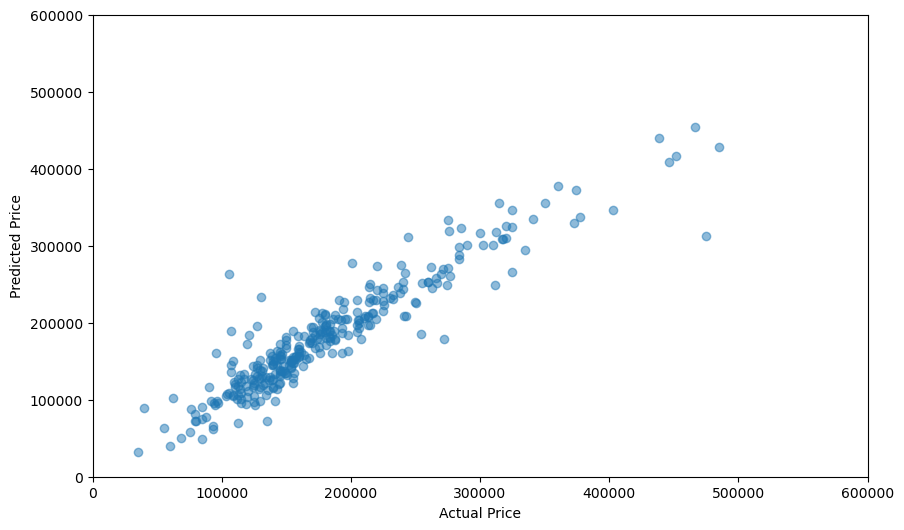

In [30]:
targets = DataLoader_dict["val"].dataset.labels
preds = model(torch.tensor(DataLoader_dict["val"].dataset.feature)).detach().numpy()

plt.figure(figsize=(10, 6))
plt.ylim(0, 600000)
plt.xlim(0, 600000)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.scatter(targets, preds, alpha=0.5)

### 推理模型

In [ ]:
test_data = pd.read_csv(r'DataSet\test.csv')
train_data = pd.read_csv(r'DataSet\train.csv')  
for col in train_data.columns:
    if col not in test_data.columns:
        print(f"missing column: {col}")
print("-"*30)
id = test_data['Id'].copy() # 保存ID列
test_data = preprocess_data(test_data, enhance_noise=False)  # 预处理测试数据
train_data = preprocess_data(train_data, enhance_noise=False)  
for col in train_data.columns:
    if col not in test_data.columns:
        print(f"Adding missing column: {col}")#填上False占位
        test_data[col] = False

Adding missing column: SalePrice
------------------------------
Adding missing column: SalePrice
Adding missing column: Utilities_NoSeWa
Adding missing column: Condition2_RRAe
Adding missing column: Condition2_RRAn
Adding missing column: Condition2_RRNn
Adding missing column: HouseStyle_2.5Fin
Adding missing column: RoofMatl_ClyTile
Adding missing column: RoofMatl_Membran
Adding missing column: RoofMatl_Metal
Adding missing column: RoofMatl_Roll
Adding missing column: Exterior1st_ImStucc
Adding missing column: Exterior1st_Stone
Adding missing column: Exterior2nd_Other
Adding missing column: Heating_Floor
Adding missing column: Heating_OthW
Adding missing column: Electrical_Mix
Adding missing column: GarageQual_Ex
Adding missing column: PoolQC_Fa
Adding missing column: MiscFeature_TenC


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31052\693886218.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(fill_value, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31052\693886218.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [ ]:
test_dataset = DataFrameDataset(test_data, label_col="SalePrice")  
model.eval()  # 评估模型
y_pred = model(torch.tensor(test_dataset.feature)).detach().numpy() # 预测结果
y_pred = pd.Series(y_pred.flatten(), name="SalePrice")
# 将预测结果与ID合并
submission = pd.DataFrame({"Id": id, "SalePrice": y_pred})
submission.to_csv("submission.csv", index=False)  # 保存预测结果到CSV文件
